In [1]:
from pyrocko import io,model,trace,util
import os
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# data folder (response removed)
workdir='../'
datadir =  os.path.join(workdir,'DATA')

# events catalogue
catdir=os.path.join(workdir,'CAT')
catname=os.path.join(catdir,'catalogue_flegrei_VLP.pf')
target_events=model.load_events(catname)

# stations list
stationsdir=os.path.join(workdir,'META_DATA')
stationsname=os.path.join(stationsdir,'stations_flegrei_INGV_final_trace_similarity.pf')
stations=model.load_stations(stationsname)

# figure dir
plotdir=os.path.join(workdir,'PLOTS/VLP_trace_similarity')

freq_min=0.09
freq_max=0.13

number_of_events=0

#dictionary : DICT [ station ] [ event name ]
dict_traces = {key.station: [] for key in stations}
for station in dict_traces:
    dict_traces[station] = {key.name: [] for key in target_events}

#dictionary containing max amplitude registered at CPOZ for each event
dict_cpoz_max = {key.name: [] for key in target_events}

for targ_ev in target_events:   # loop each event
    event_name=targ_ev.name
    ev_dir = os.path.join(datadir, event_name)
    
    if not os.path.isdir(ev_dir):
        print(event_name, 'missing data dir', ev_dir)
    elif os.path.isdir(ev_dir):
        file_name = os.path.join(ev_dir,event_name + '.mseed' )
        try:
            traces = io.load(file_name)
        except:
            print('loading single stations for event:', event_name)
            traces = []
            for station_name in stations:
                tmp_tr = io.load(os.path.join(ev_dir, event_name + '_IV_' + station_name.station + '.mseed'))
                traces.extend(tmp_tr)


        print(f'reading event: {event_name}')
        number_of_events+=1

        for tr in traces:   # normalize traces for each event relative to CPOZ
            if tr.channel=='HHZ' and tr.station=='CPOZ':
                tmp_trace_max= tr.copy()
                tmp_trace_max.lowpass(4,freq_max)
                tmp_trace_max.highpass(4,freq_min)
                tmp_trace_max.chop(tmp_trace_max.tmin+270, tmp_trace_max.tmin+450)
                max_cpoz=np.max(np.abs(tmp_trace_max.ydata) )
                dict_cpoz_max[event_name]=max_cpoz

        for tr in traces:
            if tr.channel=='HHZ':   # select HHZ channel
                #print('\nsearch!')
                for key in dict_traces:
                    #print(tr.channel,tr.station,'=?=',key)
                    if key== tr.station:    #  if target station is = to trace station
                        #print('yes!')
                        tmp_trace= tr.copy()
                        tmp_trace.lowpass(4,freq_max)
                        tmp_trace.highpass(4,freq_min)
                        tmp_trace.chop(tmp_trace.tmin+270, tmp_trace.tmin+450)
                        tmin_new = util.str_to_time('2000-01-01 00:00:0.000')
                        tmp_trace.shift(tmin_new - tmp_trace.tmin)
                        tmp_trace.ydata /= max_cpoz
                        dict_traces[tr.station][event_name].append(tmp_trace)

reading event: flegrei_2018_09_18_21_36_41
reading event: flegrei_2023_06_11_06_44_25
reading event: flegrei_2023_09_26_07_10_29
reading event: flegrei_2023_10_02_20_08_26
reading event: flegrei_2024_04_27_03_44_56
reading event: flegrei_2024_05_22_06_28_00
reading event: flegrei_2024_06_08_01_52_04
reading event: flegrei_2024_06_18_01_58_24
reading event: flegrei_2024_07_26_11_46_21
reading event: flegrei_2024_08_30_19_23_15
reading event: flegrei_2025_02_16_14_30_02
reading event: flegrei_2025_03_13_00_25_02
reading event: flegrei_2025_06_30_10_47_11
reading event: flegrei_2025_07_18_07_14_22
reading event: flegrei_2025_08_28_19_53_23
reading event: flegrei_2025_09_01_15_22_01
reading event: flegrei_2025_10_12_13_35_50
reading event: flegrei_2026_05_21_03_50_52
loading single stations for event: flegrei_2026_07_31_20_00_09
reading event: flegrei_2026_07_31_20_00_09


In [3]:
#dict_traces['CPOZ']['flegrei_2025_06_30_10_47_11'][0].snuffle()

In [4]:
# Check correlation
switch_check_correlation=False
if switch_check_correlation:
    st_corr='CPOZ'
    print(f'time shift at station {st_corr}')
    ref_tr=dict_traces[st_corr]['flegrei_2024_04_27_03_44_56'][0].copy()
    
    for ev in dict_traces[st_corr]:
        if dict_traces[st_corr][ev] != []:
            evtr = dict_traces[st_corr][ev][0].copy()
            tmp_corr=trace.correlate(ref_tr,evtr,mode='same',normalization='normal')
    
            coef_max=np.max(tmp_corr.ydata)
            coef_min=np.min(tmp_corr.ydata)
            if coef_max>np.abs(coef_min):
                coef=coef_max
            else:
                coef=coef_min
            nt= np.where(tmp_corr.ydata==coef)[0][0]
            t=tmp_corr.tmin + nt*tmp_corr.deltat
    
            print(f'{ev} shifted of t : {t} s, coef : {coef}')
            tax=np.arange(tmp_corr.tmin,tmp_corr.tmax,tmp_corr.deltat)
            plt.figure()
            plt.title(f't : {t:4.4}, coeff : {coef:5.5}')
            plt.plot(tax[12000:18000],tmp_corr.ydata[12000:18000],'k',label=f'{ev[8:]}')
            #plt.plot(tax[24000:36000],tmp_corr.ydata[24000:36000],'k',label=f'{ev[8:]}')
            #plt.plot(tax,tmp_corr.ydata,'k',label=f'{ev[8:]}')
    
            plt.plot(t,coef,'oc')
            plt.legend(loc=1)


In [5]:
ref_tr=dict_traces['CPOZ']['flegrei_2023_10_02_20_08_26'][0].copy()     # ref: flegrei_2024_04_27_03_44_56  flegrei_2023_10_02_20_08_26
xcross_coef=[]
for ev in dict_traces['CPOZ']:
    evtr = dict_traces['CPOZ'][ev][0].copy()
    tmp_corr=trace.correlate(ref_tr,evtr,mode='same',normalization='normal')

    coef_max=np.max(tmp_corr.ydata)
    coef_min=np.min(tmp_corr.ydata)
    if coef_max>=np.abs(coef_min):
        coef=coef_max
    else:
        coef=coef_min
    xcross_coef.append(coef)
    nt= np.where(tmp_corr.ydata==coef)[0][0]
    t=tmp_corr.tmin + nt*tmp_corr.deltat
    print(f'{ev} shifted of t : {t} s, coef : {coef}')

    for station in dict_traces:
        if dict_traces[station][ev] != []:
            dict_traces[station][ev][0].shift(-t)        # align 'evtr' with 'ref_tr'
            if coef<0:
                dict_traces[station][ev][0].ydata *= -1
print(f'\nMean cross correlation value: {np.mean(np.abs(xcross_coef))} +- {np.std(np.abs(xcross_coef))} ')

flegrei_2018_09_18_21_36_41 shifted of t : -0.09000000000000341 s, coef : 0.9210723456297082
flegrei_2023_06_11_06_44_25 shifted of t : 0.3200000000000074 s, coef : -0.8708027227273226
flegrei_2023_09_26_07_10_29 shifted of t : -5.349999999999994 s, coef : 0.8556324546560848
flegrei_2023_10_02_20_08_26 shifted of t : 0.0 s, coef : 1.0000000000000009
flegrei_2024_04_27_03_44_56 shifted of t : -4.939999999999998 s, coef : 0.9168137185344905
flegrei_2024_05_22_06_28_00 shifted of t : -5.1299999999999955 s, coef : 0.8985702060689669
flegrei_2024_06_08_01_52_04 shifted of t : 0.09000000000000341 s, coef : 0.9324250404001102
flegrei_2024_06_18_01_58_24 shifted of t : 0.12999999999999545 s, coef : -0.9717924709366161
flegrei_2024_07_26_11_46_21 shifted of t : -5.090000000000003 s, coef : 0.8559438413329828
flegrei_2024_08_30_19_23_15 shifted of t : 0.01999999999999602 s, coef : 0.9989012182335717
flegrei_2025_02_16_14_30_02 shifted of t : -5.299999999999997 s, coef : 0.8527294432519456
flegre

In [6]:
black_list = [['CBAC','flegrei_2026_05_21_03_50_52'],['CFMN','flegrei_2026_07_31_20_00_09']]

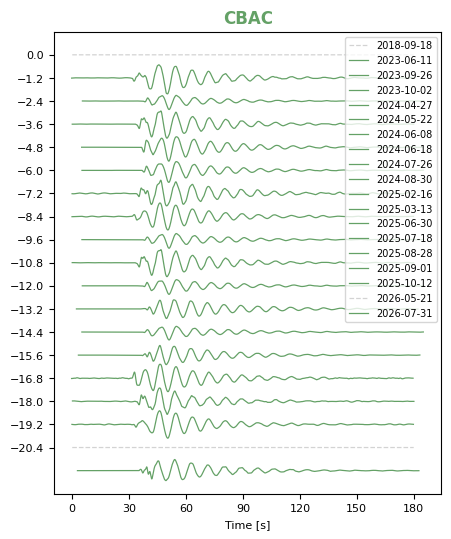

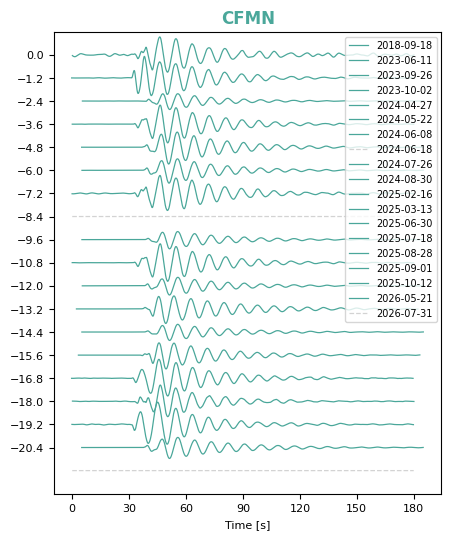

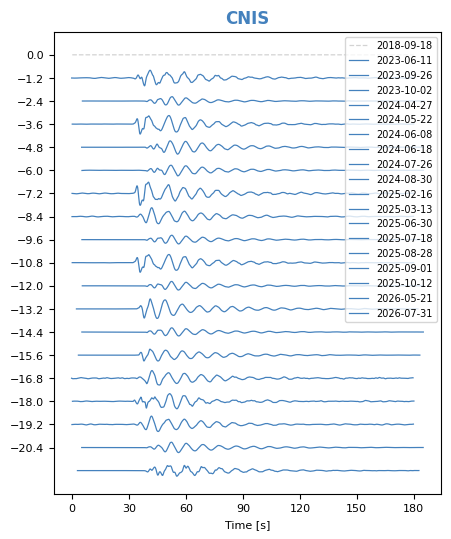

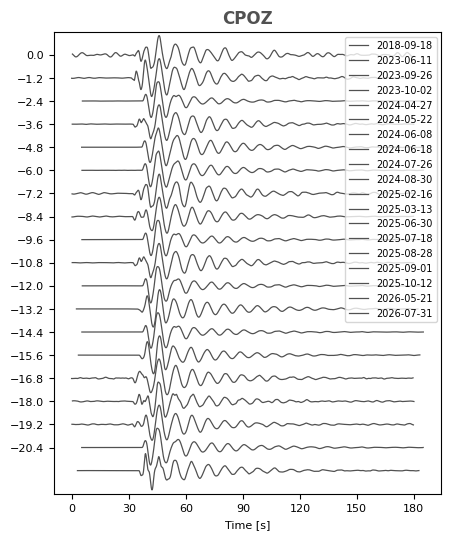

In [7]:
colors = {key.station: [] for key in stations}
colors['CBAC']='#64A166'
colors['CPOZ']='#515151'
colors['CNIS']='#4481BD'
colors['CFMN']='#4AA79A'

zero_trace=np.zeros(len(ref_tr.ydata))
tax_zero=np.arange(ref_tr.tmin,ref_tr.tmax,ref_tr.deltat) - ref_tr.tmin

for station in dict_traces:
    y_shift=0
    plt.figure(f'{station}',figsize=(5, 6))
    plt.title(f'{station}',color=colors[station],fontweight='bold')
    for ev in dict_traces[station]:
            tr_label=f'{ev[8:12]}-{ev[13:15]}-{ev[16:18]}'
            if not [station,ev] in black_list:
                try:
                    trace_plt=dict_traces[station][ev][0]
                    tax=np.arange(trace_plt.tmin,trace_plt.tmax,trace_plt.deltat) - ref_tr.tmin
                    plt.plot(tax,trace_plt.ydata - y_shift,label=tr_label,color=colors[station],linewidth=0.9)
                    y_shift+=1.2
                except:
                    plt.plot(tax_zero,zero_trace - y_shift,'--',label=tr_label,color='lightgray',linewidth=0.9)
                    y_shift+=1.2
            else:
                plt.plot(tax_zero,zero_trace - y_shift,'--',label=tr_label,color='lightgray',linewidth=0.9)
                y_shift+=1.2
    plt.ylim(-number_of_events*1.2,1.2)
    plt.legend(loc=1,fontsize=7)
    plt.yticks(ticks = list(np.arange(0,-21.1,-1.2)),fontsize=8)
    plt.xticks(ticks = list(np.arange(0,210,30)),fontsize=8)
    plt.xlabel('Time [s]',fontsize=8)
    #
    plt.savefig(plotdir+f'/{station}_similarity.pdf')

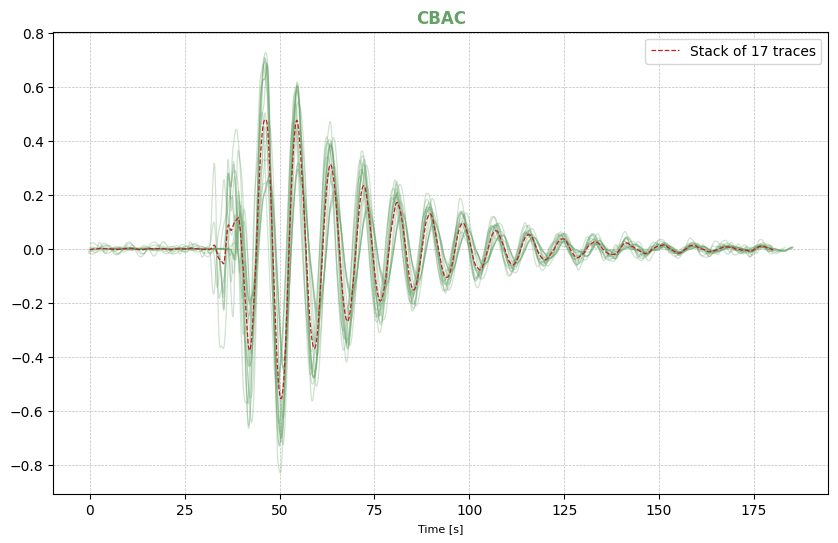

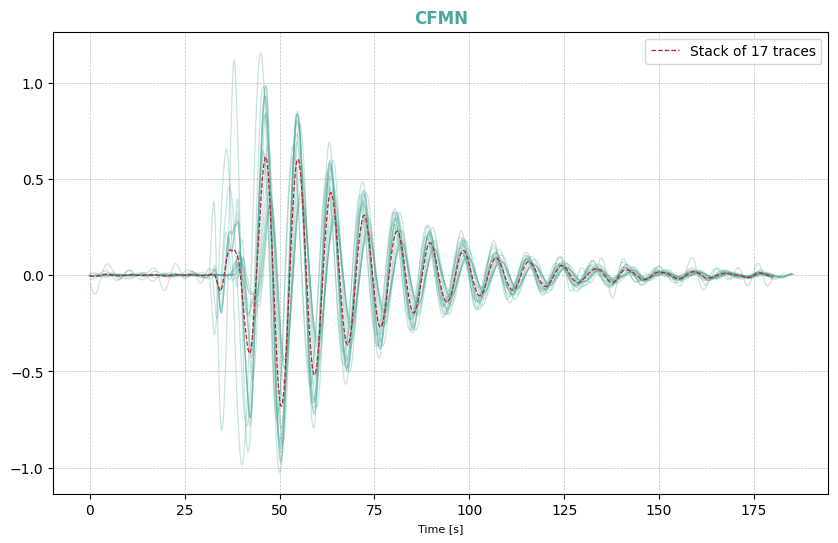

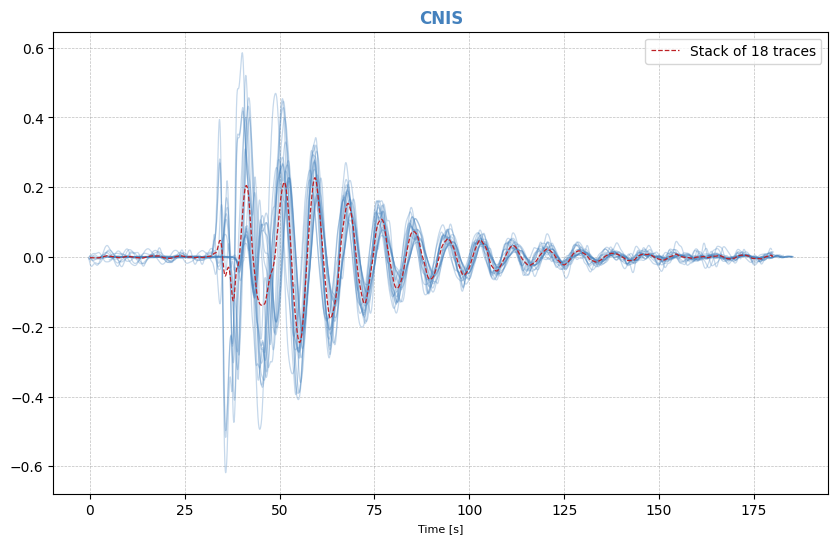

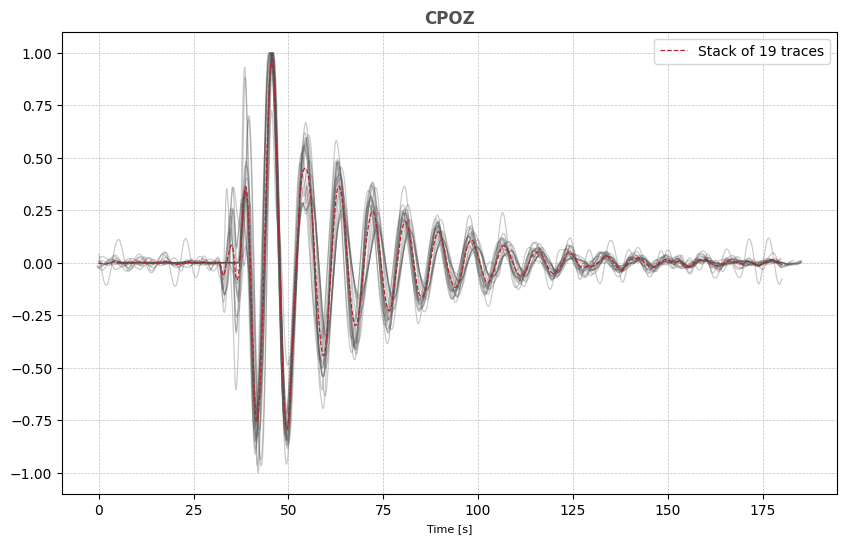

In [8]:
colors = {key.station: [] for key in stations}
colors['CBAC']='#64A166'
colors['CPOZ']='#515151'
colors['CNIS']='#4481BD'
colors['CFMN']='#4AA79A'

switch_stack = True     # add to each figure the stack (red) of the traces plotted
switch_vlp_trace_label= False # add vlp trace label 

zero_trace=np.zeros(len(ref_tr.ydata))
tax_zero=np.arange(ref_tr.tmin,ref_tr.tmax,ref_tr.deltat) - ref_tr.tmin

for station in dict_traces:
    y_shift=0
    stack_traces=[]
    plt.figure(f'{station}',figsize=(10, 6))
    plt.title(f'{station}',color=colors[station],fontweight='bold')
    plt.grid( which='both', axis='both', color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    for ev in dict_traces[station]:
            tr_label=f'{ev[8:12]}-{ev[13:15]}-{ev[16:18]}'
            if not [station,ev] in black_list:
                try:
                    trace_plt=dict_traces[station][ev][0]
                    tax=np.arange(trace_plt.tmin,trace_plt.tmax,trace_plt.deltat) - ref_tr.tmin
                    if switch_vlp_trace_label:
                        plt.plot(tax,trace_plt.ydata - y_shift,label=tr_label,color=colors[station], linewidth=0.9, alpha=0.2)
                    else:
                        plt.plot(tax,trace_plt.ydata - y_shift,color=colors[station], linewidth=0.9, alpha=0.3)
                    stack_traces.append(trace_plt)
                    #y_shift+=1.2
                except:
                    continue
                #plt.plot(tax_zero,zero_trace - y_shift,'--',label=tr_label,color='lightgray', linewidth=0.9)
                #y_shift+=1.2
    #plt.ylim(-number_of_events*1.2,1.2)
    #plt.legend(loc=1,fontsize=7)
    #plt.yticks(ticks = list(np.arange(0,-29.6,-1.2)),fontsize=8)
    #plt.xticks(ticks = list(np.arange(0,210,30)),fontsize=8)
    if switch_stack and stack_traces!=[]:
        # stack of the traces above, keeping the shift and the polarity they are
        # drawn with: dict_traces is already aligned/flipped by the xcorr cell, so
        # each trace is resampled on the reference time axis before averaging
        stack=np.mean([np.interp(tax_zero,
                                 tr.tmin - ref_tr.tmin + np.arange(len(tr.ydata))*tr.deltat,
                                 tr.ydata, left=0., right=0.)
                       for tr in stack_traces],axis=0)
        plt.plot(tax_zero,stack - y_shift,'--',color='#BD2025', linewidth=0.9,
                 label=f'Stack of {len(stack_traces)} traces')
        plt.legend()
    plt.xlabel('Time [s]',fontsize=8)
    #
    plt.savefig(plotdir+f'/{station}_similarity_condensed.pdf')

VLP polarity at zero lag, reference flegrei_2023_10_02_20_08_26
  flegrei_2018_09_18_21_36_41 : xcorr(lag=0) +0.919
  flegrei_2023_06_11_06_44_25 : xcorr(lag=0) -0.845   -> flipped
  flegrei_2023_09_26_07_10_29 : xcorr(lag=0) -0.538   -> flipped
  flegrei_2023_10_02_20_08_26 : xcorr(lag=0) +1.000
  flegrei_2024_04_27_03_44_56 : xcorr(lag=0) -0.807   -> flipped
  flegrei_2024_05_22_06_28_00 : xcorr(lag=0) -0.704   -> flipped
  flegrei_2024_06_08_01_52_04 : xcorr(lag=0) +0.930
  flegrei_2024_06_18_01_58_24 : xcorr(lag=0) -0.967   -> flipped
  flegrei_2024_07_26_11_46_21 : xcorr(lag=0) -0.622   -> flipped
  flegrei_2024_08_30_19_23_15 : xcorr(lag=0) +0.999
  flegrei_2025_02_16_14_30_02 : xcorr(lag=0) -0.583   -> flipped
  flegrei_2025_03_13_00_25_02 : xcorr(lag=0) +0.137
  flegrei_2025_06_30_10_47_11 : xcorr(lag=0) -0.617   -> flipped
  flegrei_2025_07_18_07_14_22 : xcorr(lag=0) +0.625
  flegrei_2025_08_28_19_53_23 : xcorr(lag=0) -0.951   -> flipped
  flegrei_2025_09_01_15_22_01 : xcorr(l

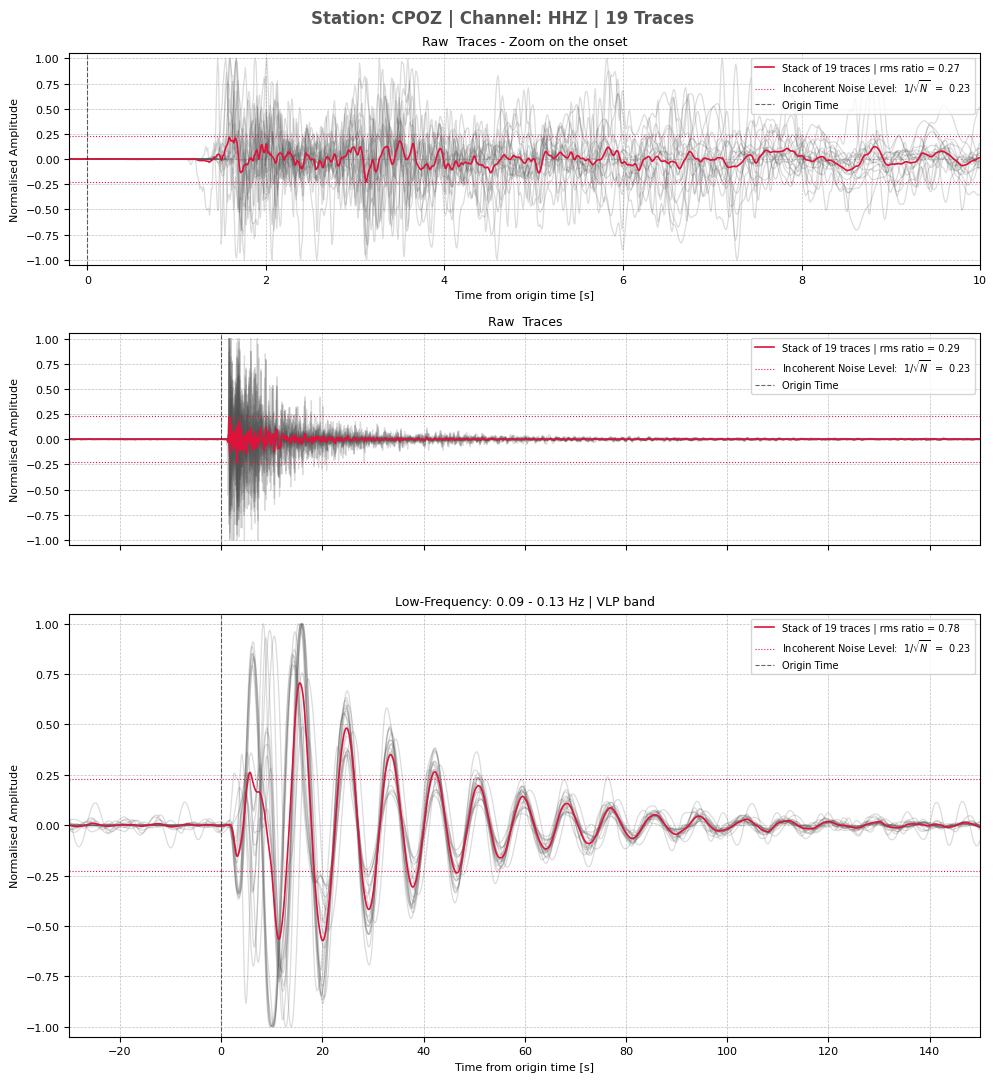

In [15]:
# =========================================================================
#  CPOZ HHZ, all events overlaid, aligned on the CATALOGUE ORIGIN TIME
#  (t = 0 s); the traces are never shifted in time.
#      row 1 : raw (or band-passed, see filter_top), zoom on the onset
#      row 2 : the same trace as row 1, full window
#      row 3 : 0.09 - 0.13 Hz (VLP band)
#  Row 1 is dropped when switch_zoom = False, leaving a two-row figure.
#  Raw traces come from different sources and locations and should stack
#  destructively, the VLP band from the same source and constructively.
#  Every panel is normalised on the window it displays -> all in [-1, 1].
#  NB: DATA/ holds raw counts, the instrument response is NOT removed.
#  CITE : Neidell & Taner, 1971
# =========================================================================
station_plot  = 'CPOZ'
t_pre, t_post           = 30., 150.   # full window around the origin time [s]
switch_zoom   = True        # True  -> 3 rows, the first one zoomed on the onset
                            # False -> 2 rows, full window and VLP band only
t_pre_zoom, t_post_zoom = 0.2, 10.     # zoom window of the first row [s]
filter_top    = False       # rows 1 and 2: False -> raw trace, True -> band-pass
freq_min_top, freq_max_top = 0.5, 2.0    # band used when filter_top = True
detrend       = True        # offset + linear trend removal on the rows 1-2 traces
norm_mode     = 'max'       # 'max' -> peak = 1  |  'rms' -> std = 1
rms_t0        = 0.          # rms ratio measured from here to the right edge
                            # of each panel [s from the origin time]
flip_polarity = True        # VLP panel only: invert the traces that are in anti
                            # phase with the reference, i.e. negative xcorr AT
                            # ZERO LAG.  The lag is never applied: half a VLP
                            # period (~4.5 s) is degenerate with a polarity flip,
                            # so the sign of the largest |xcorr| over all lags is
                            # meaningless unless its shift is applied too.
ref_event     = 'flegrei_2023_10_02_20_08_26'    # reference for the polarity

col     = colors[station_plot] if colors.get(station_plot) else '#515151'
ev_time = {e.name: e.time for e in target_events}

def normalize(y, mode=norm_mode):
    y = np.asarray(y, dtype=float)
    scale = np.max(np.abs(y)) if mode == 'max' else np.std(y)
    return y / scale if scale > 0 else y

def detrend_window(tr):     # remove offset and linear drift on the cut window
    x = np.arange(len(tr.ydata))
    tr.ydata -= np.polyval(np.polyfit(x, tr.ydata, 1), x)

raw_traces, vlp_traces = {}, {}      # event name -> trace, cut on its origin time

for targ_ev in target_events:
    ev     = targ_ev.name
    ev_dir = os.path.join(datadir, ev)
    if [station_plot, ev] in black_list or not os.path.isdir(ev_dir):
        continue
    try:
        traces = io.load(os.path.join(ev_dir, ev + '.mseed'))
    except:
        traces = io.load(os.path.join(ev_dir, ev + '_IV_' + station_plot + '.mseed'))

    tr_raw = None
    for tr in traces:
        if tr.channel == 'HHZ' and tr.station == station_plot:
            tr_raw = tr.copy()
    if tr_raw is None:
        print(ev, ': no', station_plot, 'HHZ trace')
        continue

    tr_raw.ydata = tr_raw.ydata.astype(np.float64)      # raw mseed is int32

    # band-passes on the whole record, exactly as in the cells above
    tr_vlp = tr_raw.copy()          # copied before tr_raw is possibly filtered
    tr_vlp.lowpass(4, freq_max)
    tr_vlp.highpass(4, freq_min)

    if filter_top:                  # optional band-pass of the first two rows
        tr_raw.lowpass(4, freq_max_top)
        tr_raw.highpass(4, freq_min_top)

    # cut both on the origin time (1 s of margin, consumed by the resampling)
    for tr_cut, store in ((tr_raw, raw_traces), (tr_vlp, vlp_traces)):
        tr_cut.chop(targ_ev.time - t_pre - 1., targ_ev.time + t_post + 1.)
        store[ev] = tr_cut

    if detrend:
        detrend_window(tr_raw)

# common time axis: t = 0 is the origin time of every event
deltat = min(tr.deltat for tr in raw_traces.values())
t_ax   = np.arange(-t_pre, t_post, deltat)

def on_origin_time(tr, ev):     # resample on t_ax, i.e. align on the origin time
    t = (tr.tmin - ev_time[ev]) + np.arange(len(tr.ydata)) * tr.deltat
    return np.interp(t_ax, t, tr.ydata)

y_raw = {ev: on_origin_time(tr, ev) for ev, tr in raw_traces.items()}
y_vlp = {ev: on_origin_time(tr, ev) for ev, tr in vlp_traces.items()}

# ------------------------------------- polarity of the VLP traces, at zero lag
sign = {ev: 1. for ev in y_vlp}
if flip_polarity and y_vlp:
    ref   = ref_event if ref_event in y_vlp else list(y_vlp)[0]
    y_ref = y_vlp[ref]
    print(f'VLP polarity at zero lag, reference {ref}')
    for ev, y in y_vlp.items():
        coef = np.dot(y_ref, y) / np.sqrt(np.sum(y_ref ** 2) * np.sum(y ** 2))
        sign[ev] = -1. if coef < 0 else 1.
        print(f'  {ev} : xcorr(lag=0) {coef:+.3f}' + ('   -> flipped' if coef < 0 else ''))
    print(f'  {sum(1 for s in sign.values() if s < 0)} traces flipped')

# ---------------------------------------------------------------- plotting
label_top = (f'High-Frequency: {freq_min_top} - {freq_max_top} Hz | VT band' if filter_top
             else 'Raw  Traces')

panels = [(y_raw, label_top + ' - Zoom on the onset',
           (-t_pre_zoom, t_post_zoom)),
          (y_raw, label_top,
           (-t_pre, t_post)),
          ({ev: y * sign[ev] for ev, y in y_vlp.items()},
           f'Low-Frequency: {freq_min} - {freq_max} Hz | VLP band',
           (-t_pre, t_post))]
if not switch_zoom:
    panels = panels[1:]                         # drop the zoomed row

N = len(y_raw)
# the last row (VLP band) is twice as tall as each of the rows above it
fig, axes = plt.subplots(len(panels), 1, sharey=True,
                         figsize=(10, 11) if switch_zoom else (10, 8),
                         gridspec_kw={'height_ratios': [1] * (len(panels) - 1) + [2]})
fig.suptitle(f'Station: {station_plot} | Channel: HHZ | {N} Traces',
             color=col, fontweight='bold')

for ax, (ys, subtitle, xlim) in zip(axes, panels):
    m_win = (t_ax >= xlim[0]) & (t_ax <= xlim[1])
    t_win = t_ax[m_win]

    # each panel is normalised on the window it shows
    A = np.array([normalize(y[m_win]) for y in ys.values()])
    for y in A:
        ax.plot(t_win, y, color=col, linewidth=0.9, alpha=0.2)

    # coherence: rms of the stack over the mean rms of the single traces.
    # 1 = identical traces, 1/sqrt(N) = mutually uncorrelated traces
    stack      = A.mean(axis=0)
    m_rms      = t_win >= rms_t0
    rms_single = np.mean(np.sqrt(np.mean(A[:, m_rms] ** 2, axis=1)))
    rms_ratio  = np.sqrt(np.mean(stack[m_rms] ** 2)) / rms_single

    ax.plot(t_win, stack, color='crimson', linewidth=1.2,
            label=f'Stack of {N} traces | rms ratio = {rms_ratio:.2f}')
    ax.axhline(1. / np.sqrt(N), color='crimson', linestyle=':', linewidth=0.8,
               label=f'Incoherent Noise Level:  1/$\\sqrt{{N}}$  =  {1./np.sqrt(N):.2f}')
    ax.axhline(-1. / np.sqrt(N), color='crimson', linestyle=':', linewidth=0.8)
    ax.axvline(0., color='k', linestyle='--', linewidth=0.8, alpha=0.6,
               label='Origin Time')

    ax.set_title(subtitle, fontsize=9)
    ax.grid(which='both', axis='both', color='gray', linestyle='--',
            linewidth=0.5, alpha=0.5)
    ax.set_ylabel('Normalised Amplitude', fontsize=8)
    ax.set_xlim(*xlim)
    ax.set_ylim(-1.05, 1.05)
    ax.legend(loc=1, fontsize=7)
    ax.tick_params(labelsize=8)

axes[-2].tick_params(labelbottom=False)         # same axis as the panel below
axes[-1].set_xlabel('Time from origin time [s]', fontsize=8)
if switch_zoom:                                 # the zoomed row has its own axis
    axes[0].set_xlabel('Time from origin time [s]', fontsize=8)
fig.tight_layout()
fig.savefig(plotdir + f'/{station_plot}_raw_vs_filtered.pdf')